# Pregunta 2

En esta notebook voy a implementar algunas partes base para trabajar con difusión anisotrópica.

Primero uso una imagen sintética simple para probar las funciones y revisar que los cálculos estén funcionando como espero.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

## Imagen test

Primero creo una imagen pequeña con un cuadrado en el centro. La voy a usar solamente para probar las funciones que se implementan después.

Imagen test
Tamano: (20, 20)
Minimo: 0.0
Maximo: 1.0


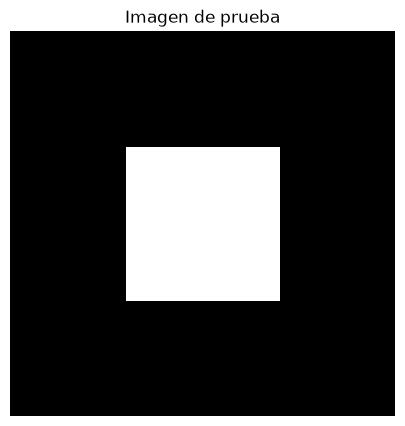

In [21]:
# imagen test
tamano = 20

imagen_test = np.zeros((tamano, tamano))

imagen_test[6:14, 6:14] = 1


print("Imagen test")
print("Tamano:", imagen_test.shape)
print("Minimo:", np.min(imagen_test))
print("Maximo:", np.max(imagen_test))


plt.figure(figsize=(5, 5))

plt.imshow(
    imagen_test,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Imagen de prueba")
plt.axis("off")

plt.show()

## Diferencias finitas

Para la difusión necesito calcular las diferencias entre cada píxel y sus vecinos en cuatro direcciones: norte, sur, izquierda y derecha.

En los bordes replico el valor más cercano para mantener el mismo tamaño de la imagen.

In [22]:
def diferencias_direccion(imagen):

    # bordes
    imagen_pad = np.pad(
        imagen,
        1,
        mode="edge"
    )

    centro = imagen_pad[1:-1, 1:-1]

    diff_norte = imagen_pad[:-2, 1:-1] - centro
    diff_sur = imagen_pad[2:, 1:-1] - centro
    diff_left = imagen_pad[1:-1, :-2] - centro
    diff_right = imagen_pad[1:-1, 2:] - centro

    return diff_norte, diff_sur, diff_left, diff_right

### Tests de las diferencias

Pruebo las cuatro diferencias con la imagen anterior para revisar sus dimensiones y los valores que entregan.

In [23]:
diff_norte, diff_sur, diff_left, diff_right = (
    diferencias_direccion(imagen_test)
)


print("Diferencias finitas")

print("\nNorte")
print("Tamano:", diff_norte.shape)
print("Minimo:", np.min(diff_norte))
print("Maximo:", np.max(diff_norte))

print("\nSur")
print("Tamano:", diff_sur.shape)
print("Minimo:", np.min(diff_sur))
print("Maximo:", np.max(diff_sur))

print("\nLeft")
print("Tamano:", diff_left.shape)
print("Minimo:", np.min(diff_left))
print("Maximo:", np.max(diff_left))

print("\nRight")
print("Tamano:", diff_right.shape)
print("Minimo:", np.min(diff_right))
print("Maximo:", np.max(diff_right))

Diferencias finitas

Norte
Tamano: (20, 20)
Minimo: -1.0
Maximo: 1.0

Sur
Tamano: (20, 20)
Minimo: -1.0
Maximo: 1.0

Left
Tamano: (20, 20)
Minimo: -1.0
Maximo: 1.0

Right
Tamano: (20, 20)
Minimo: -1.0
Maximo: 1.0


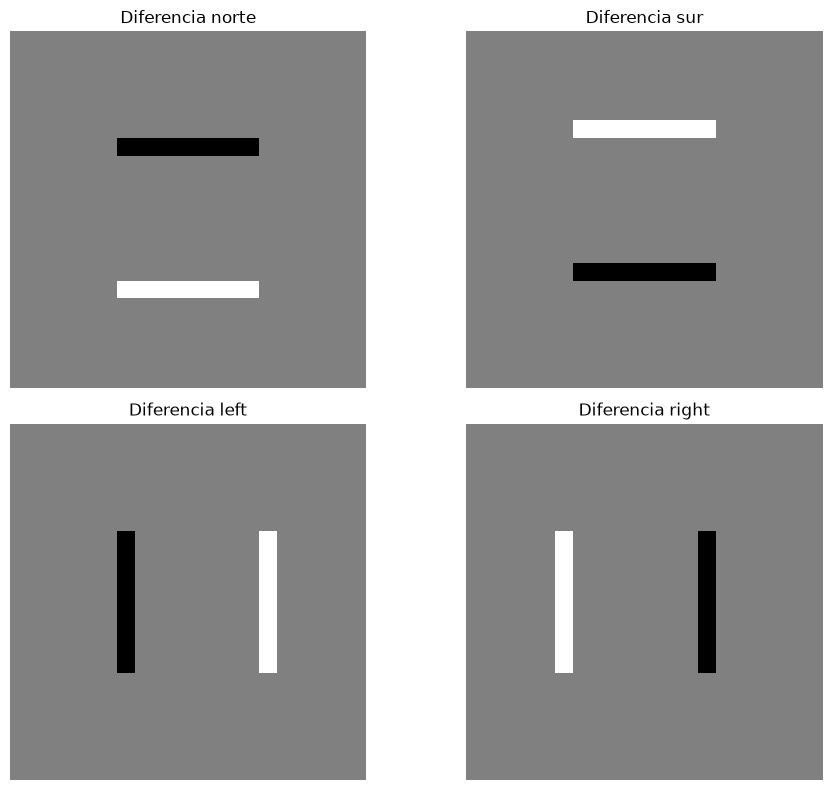

In [24]:
plt.figure(figsize=(10, 8))


plt.subplot(2, 2, 1)
plt.imshow(diff_norte, cmap="gray")
plt.title("Diferencia norte")
plt.axis("off")


plt.subplot(2, 2, 2)
plt.imshow(diff_sur, cmap="gray")
plt.title("Diferencia sur")
plt.axis("off")


plt.subplot(2, 2, 3)
plt.imshow(diff_left, cmap="gray")
plt.title("Diferencia left")
plt.axis("off")


plt.subplot(2, 2, 4)
plt.imshow(diff_right, cmap="gray")
plt.title("Diferencia right")
plt.axis("off")


plt.tight_layout()
plt.show()

## Gradiente y Laplaciano

Con las diferencias anteriores calculo la magnitud del gradiente y el Laplaciano.

Para el gradiente aproximo las derivadas horizontal y vertical usando las diferencias de lados opuestos. Para el Laplaciano sumo las cuatro diferencias direccionales.

In [25]:
def calcular_gradiente(imagen):

    diff_norte, diff_sur, diff_left, diff_right = (
        diferencias_direccion(imagen)
    )

    grad_x = (diff_right - diff_left) / 2
    grad_y = (diff_sur - diff_norte) / 2

    gradiente = np.sqrt(
        grad_x**2 + grad_y**2
    )

    return gradiente


def calcular_laplaciano(imagen):

    diff_norte, diff_sur, diff_left, diff_right = (
        diferencias_direccion(imagen)
    )

    laplaciano = (
        diff_norte
        + diff_sur
        + diff_left
        + diff_right
    )

    return laplaciano

### Test del gradiente y Laplaciano

Calculo los dos sobre la misma imagen para revisar sus valores y ver en qué zonas aparece una mayor respuesta.

In [26]:
gradiente_test = calcular_gradiente(imagen_test)
laplaciano_test = calcular_laplaciano(imagen_test)


print("Gradiente")
print("Tamano:", gradiente_test.shape)
print("Minimo:", np.min(gradiente_test))
print("Maximo:", np.max(gradiente_test))


print("\nLaplaciano")
print("Tamano:", laplaciano_test.shape)
print("Minimo:", np.min(laplaciano_test))
print("Maximo:", np.max(laplaciano_test))

Gradiente
Tamano: (20, 20)
Minimo: 0.0
Maximo: 0.7071067811865476

Laplaciano
Tamano: (20, 20)
Minimo: -2.0
Maximo: 1.0


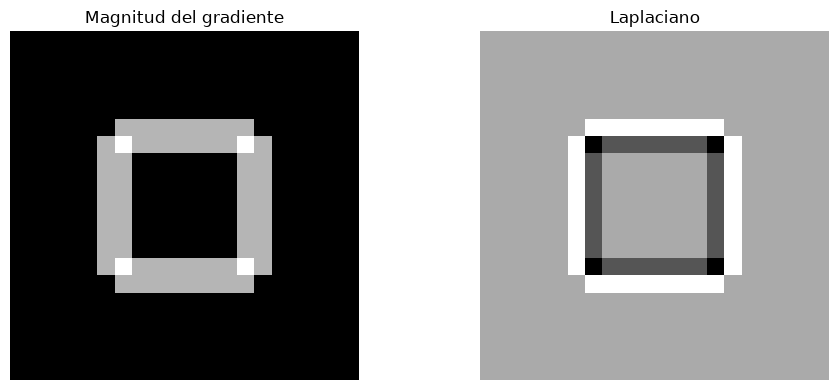

In [27]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.imshow(
    gradiente_test,
    cmap="gray"
)
plt.title("Magnitud del gradiente")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(
    laplaciano_test,
    cmap="gray"
)
plt.title("Laplaciano")
plt.axis("off")


plt.tight_layout()
plt.show()

## Coeficiente de difusión TV

Para el primer caso uso el coeficiente de Variación Total regularizada indicado en el enunciado:

$$
c_{TV}=\frac{1}{\sqrt{|\nabla u|^2+\epsilon^2}}
$$

Dejo epsilon como parámetro para poder cambiarlo después en las pruebas.

In [28]:
def coeficiente_tv(imagen, epsilon):

    gradiente = calcular_gradiente(imagen)

    c_tv = 1 / np.sqrt(
        gradiente**2 + epsilon**2
    )

    return c_tv

### Test del coeficiente TV

Primero pruebo el coeficiente con epsilon igual a 0.1 para revisar su rango y ver cómo cambia entre las zonas planas y los bordes.

In [29]:
epsilon_test = 0.1

c_tv_test = coeficiente_tv(
    imagen_test,
    epsilon_test
)


print("Coeficiente TV")
print("Epsilon:", epsilon_test)
print("Tamano:", c_tv_test.shape)
print("Minimo:", np.min(c_tv_test))
print("Maximo:", np.max(c_tv_test))

Coeficiente TV
Epsilon: 0.1
Tamano: (20, 20)
Minimo: 1.4002800840280096
Maximo: 10.0


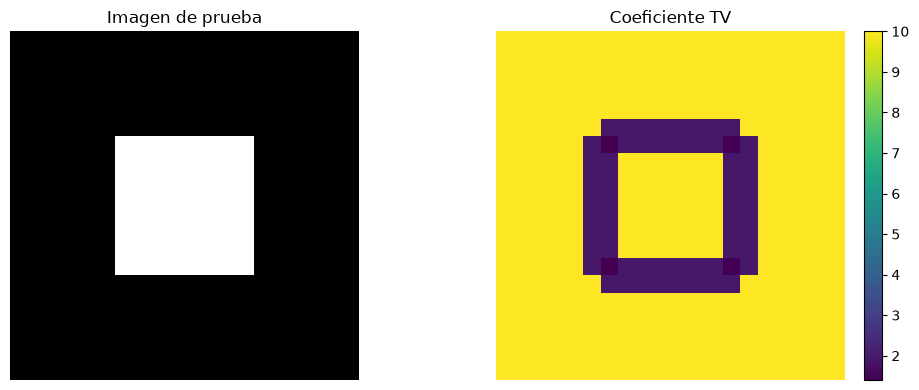

In [30]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.imshow(
    imagen_test,
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Imagen de prueba")
plt.axis("off")


plt.subplot(1, 2, 2)
mapa_tv = plt.imshow(
    c_tv_test,
    cmap="viridis"
)
plt.title("Coeficiente TV")

plt.colorbar(
    mapa_tv,
    fraction=0.046,
    pad=0.04
)

plt.axis("off")


plt.tight_layout()
plt.show()

## Difusión anisotrópica

Ahora implemento la actualización explícita usando las diferencias en las cuatro direcciones.

En cada iteración vuelvo a calcular el coeficiente TV usando la imagen actual. La actualización que uso es:

$$
u^{t+1} = u^t + \lambda \left( c_N d_N + c_S d_S + c_L d_L + c_R d_R \right)
$$

Para cada dirección uso el promedio entre el coeficiente del píxel actual y el del vecino correspondiente.

In [31]:
def difusion_anisotropica(
    imagen,
    lambda_value,
    num_iteraciones,
    epsilon
):

    imagen_actual = imagen.copy()

    for iteracion in range(num_iteraciones):

        # diferencias
        diff_norte, diff_sur, diff_left, diff_right = (
            diferencias_direccion(imagen_actual)
        )

        # coeficiente
        c = coeficiente_tv(
            imagen_actual,
            epsilon
        )

        # bordes c
        c_pad = np.pad(
            c,
            1,
            mode="edge"
        )

        c_norte = (
            c + c_pad[:-2, 1:-1]
        ) / 2

        c_sur = (
            c + c_pad[2:, 1:-1]
        ) / 2

        c_left = (
            c + c_pad[1:-1, :-2]
        ) / 2

        c_right = (
            c + c_pad[1:-1, 2:]
        ) / 2


        # actualizar
        cambio = (
            c_norte * diff_norte
            + c_sur * diff_sur
            + c_left * diff_left
            + c_right * diff_right
        )

        imagen_actual = (
            imagen_actual
            + lambda_value * cambio
        )

    return imagen_actual

### Paso temporal

Antes de probar la difusión reviso un límite simple para lambda usando el valor máximo del coeficiente.

Para una vecindad de cuatro direcciones uso:

$$
\lambda \leq \frac{1}{4c_{\max}}
$$

Con este valor puedo revisar si el lambda elegido está dentro del límite antes de hacer las iteraciones.

In [32]:
# revisar lambda
max_c = np.max(c_tv_test)

lambda_max = 1 / (4 * max_c)

lambda_test = 0.02

check_lambda = lambda_test <= lambda_max


print("Estabilidad")
print("C max:", max_c)
print("Lambda max:", lambda_max)
print("Lambda prueba:", lambda_test)

if check_lambda:
    print("Lambda estable")
else:
    print("Revisar lambda")

Estabilidad
C max: 10.0
Lambda max: 0.025
Lambda prueba: 0.02
Lambda estable


### Test de la difusión

Pruebo la difusión sobre la imagen sintética usando el coeficiente TV. Primero uso pocas iteraciones para revisar que la actualización funcione correctamente.

In [33]:
num_iteraciones = 10

imagen_difusion = difusion_anisotropica(
    imagen_test,
    lambda_test,
    num_iteraciones,
    epsilon_test
)


print("Difusion TV")
print("Lambda:", lambda_test)
print("Iteraciones:", num_iteraciones)
print("Epsilon:", epsilon_test)
print("Minimo:", np.min(imagen_difusion))
print("Maximo:", np.max(imagen_difusion))

Difusion TV
Lambda: 0.02
Iteraciones: 10
Epsilon: 0.1
Minimo: 0.0
Maximo: 0.9813692516066473


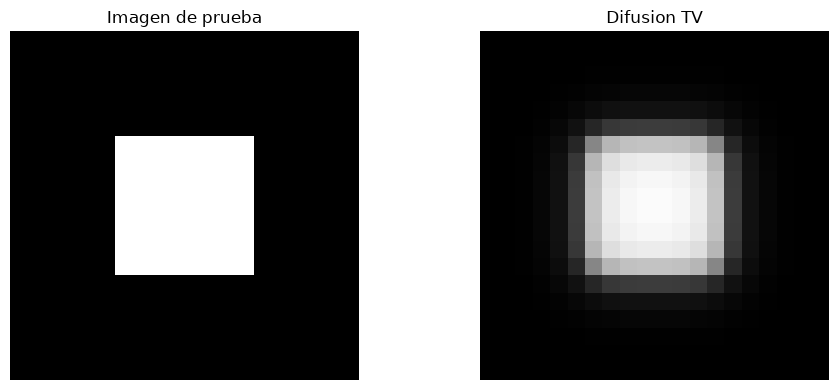

In [34]:
plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)
plt.imshow(
    imagen_test,
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Imagen de prueba")
plt.axis("off")


plt.subplot(1, 2, 2)
plt.imshow(
    imagen_difusion,
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Difusion TV")
plt.axis("off")


plt.tight_layout()
plt.show()

## Tests básicos

Para revisar un poco mejor el comportamiento de la implementación hago algunas pruebas simples cambiando el número de iteraciones y el valor de epsilon.

No hago un ajuste completo de parámetros, sino que estas pruebas son para ver cómo cambia el resultado de la difusión.

In [35]:
iteraciones_values = [5, 10, 30]

resultados_iteraciones = []


for num_iter in iteraciones_values:

    resultado = difusion_anisotropica(
        imagen_test,
        lambda_test,
        num_iter,
        epsilon_test
    )

    resultados_iteraciones.append(resultado)

    print("\nIteraciones:", num_iter)
    print("Minimo:", np.min(resultado))
    print("Maximo:", np.max(resultado))


Iteraciones: 5
Minimo: 0.0
Maximo: 0.9986211265101663

Iteraciones: 10
Minimo: 0.0
Maximo: 0.9813692516066473

Iteraciones: 30
Minimo: 0.0019327409345128103
Maximo: 0.807412867177166


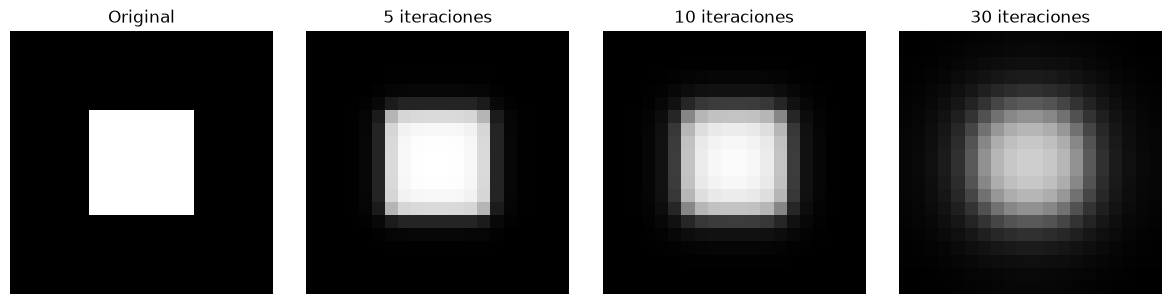

In [36]:
plt.figure(figsize=(12, 3))


plt.subplot(1, 4, 1)
plt.imshow(
    imagen_test,
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Original")
plt.axis("off")


plt.subplot(1, 4, 2)
plt.imshow(
    resultados_iteraciones[0],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("5 iteraciones")
plt.axis("off")


plt.subplot(1, 4, 3)
plt.imshow(
    resultados_iteraciones[1],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("10 iteraciones")
plt.axis("off")


plt.subplot(1, 4, 4)
plt.imshow(
    resultados_iteraciones[2],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("30 iteraciones")
plt.axis("off")


plt.tight_layout()
plt.show()

### Efecto de epsilon

Ahora comparo dos valores de epsilon manteniendo el mismo lambda y el mismo número de iteraciones.

Al cambiar epsilon también cambia el rango del coeficiente TV, por lo que el resultado de la difusión también cambia.

In [37]:
epsilon_values = [0.1, 0.2]

resultados_epsilon = []
mapas_epsilon = []


for epsilon in epsilon_values:

    mapa_c = coeficiente_tv(
        imagen_test,
        epsilon
    )

    resultado = difusion_anisotropica(
        imagen_test,
        lambda_test,
        10,
        epsilon
    )

    mapas_epsilon.append(mapa_c)
    resultados_epsilon.append(resultado)

    max_c = np.max(mapa_c)
    lambda_max = 1 / (4 * max_c)

    print("\nEpsilon:", epsilon)
    print("C minimo:", np.min(mapa_c))
    print("C maximo:", max_c)
    print("Lambda max:", lambda_max)
    print("Resultado max:", np.max(resultado))


Epsilon: 0.1
C minimo: 1.4002800840280096
C maximo: 10.0
Lambda max: 0.025
Resultado max: 0.9813692516066473

Epsilon: 0.2
C minimo: 1.3608276348795432
C maximo: 5.0
Lambda max: 0.05
Resultado max: 0.9948512912570274


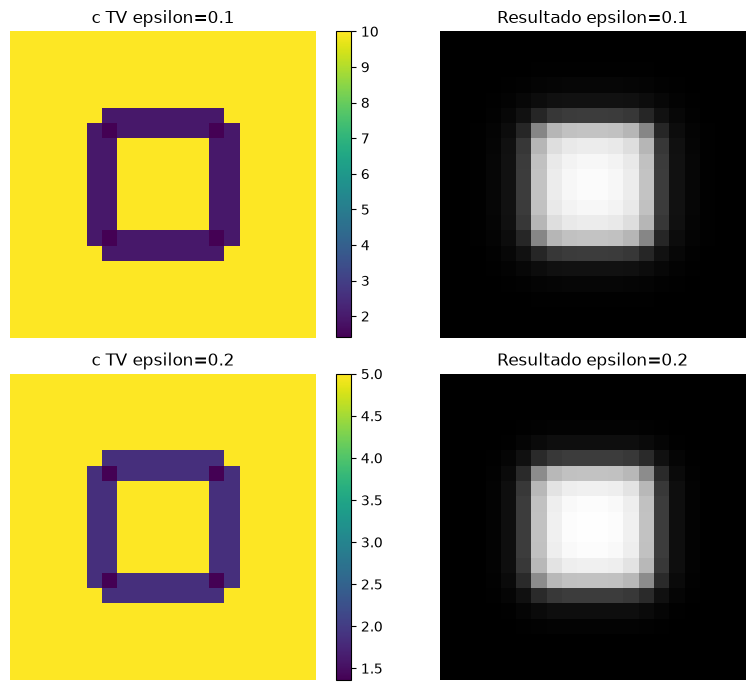

In [38]:
plt.figure(figsize=(10, 7))


plt.subplot(2, 2, 1)
mapa_1 = plt.imshow(
    mapas_epsilon[0],
    cmap="viridis"
)
plt.title("c TV epsilon=0.1")
plt.axis("off")
plt.colorbar(
    mapa_1,
    fraction=0.046,
    pad=0.04
)


plt.subplot(2, 2, 2)
plt.imshow(
    resultados_epsilon[0],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Resultado epsilon=0.1")
plt.axis("off")


plt.subplot(2, 2, 3)
mapa_2 = plt.imshow(
    mapas_epsilon[1],
    cmap="viridis"
)
plt.title("c TV epsilon=0.2")
plt.axis("off")
plt.colorbar(
    mapa_2,
    fraction=0.046,
    pad=0.04
)


plt.subplot(2, 2, 4)
plt.imshow(
    resultados_epsilon[1],
    cmap="gray",
    vmin=0,
    vmax=1
)
plt.title("Resultado epsilon=0.2")
plt.axis("off")


plt.tight_layout()
plt.show()

### Comentario de los tests

Al aumentar el número de iteraciones se nota una mayor difusión. Con 5 iteraciones el valor máximo todavía queda muy cerca de 1, mientras que con 30 iteraciones baja aproximadamente a 0.81 y el cuadrado se ve más suavizado.

También se nota una diferencia al cambiar epsilon. Con epsilon=0.1 el valor máximo de (c) es 10, mientras que con epsilon=0.2 baja a 5. Usando el mismo lambda y 10 iteraciones, con epsilon=0.1 se obtiene un poco más de difusión.

Estas pruebas son solo para revisar el funcionamiento básico de la implementación y no corresponden a un ajuste completo de los parámetros.